## Cheating Surveillance Project

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [6]:
df = pd.read_csv("realistic_cheating_data.csv")

# Display the first few rows of the dataset
print(df.head())   
             

          timestamp head_direction     gaze_direction  mobile_detected  \
0  2025-05-02 21:00   Looking Down       Looking Down            False   
1  2025-05-02 21:01  Looking Right       Looking Down            False   
2  2025-05-02 21:02   Looking Left  Looking at Screen            False   
3  2025-05-02 21:03   Looking Left       Looking Left             True   
4  2025-05-02 21:04   Looking Down       Looking Left            False   

   cheating  
0         0  
1         0  
2         0  
3         1  
4         0  


C:\Users\DESKTOP\AppData\Local\Temp\ipykernel_1964\2697588213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cheating', data=df, palette='Set2')


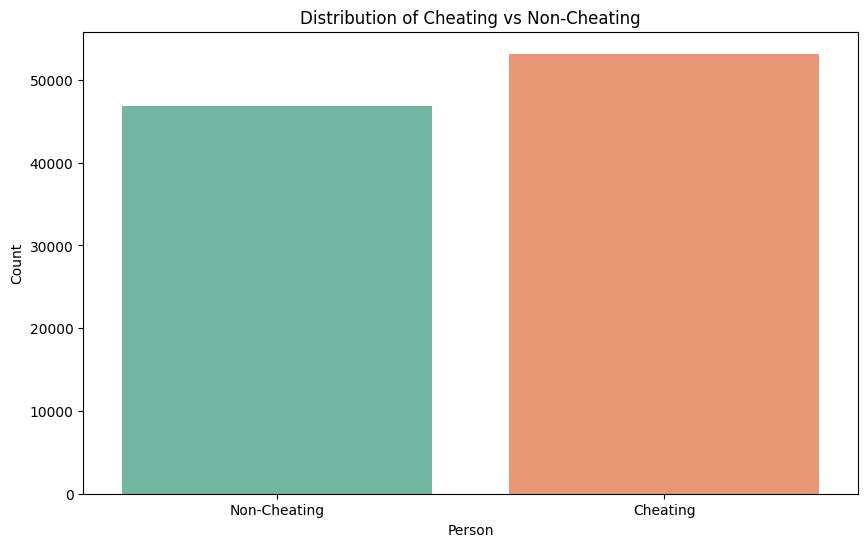

In [7]:
# Visualize the data distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='cheating', data=df, palette='Set2')
plt.title("Distribution of Cheating vs Non-Cheating")
plt.xlabel("Person")
plt.ylabel("Count")
plt.xticks([0, 1], ['Non-Cheating', 'Cheating'])
plt.show()

C:\Users\DESKTOP\AppData\Local\Temp\ipykernel_1964\1647448053.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_counts.index, y=head_counts.values, palette="viridis")


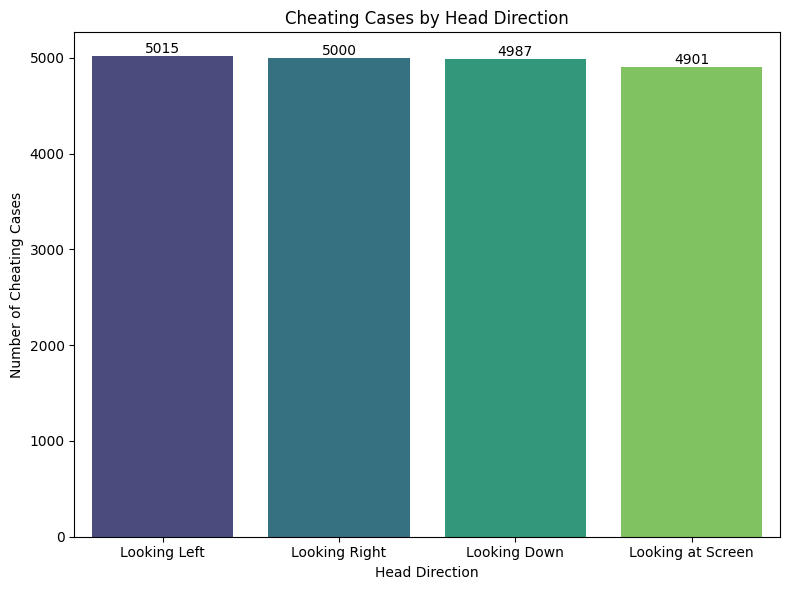

In [ ]:
# Filter only cheating cases by Head Direction
cheating_cases = df[df['mobile_detected'] == 1]

# Count the number of cheating cases for each head direction
head_counts = cheating_cases['head_direction'].value_counts()

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x=head_counts.index, y=head_counts.values, palette="viridis")
plt.title('Cheating Cases by Head Direction')
plt.xlabel('Head Direction')
plt.ylabel('Number of Cheating Cases')

# Add data labels on bars
for i, v in enumerate(head_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

C:\Users\DESKTOP\AppData\Local\Temp\ipykernel_1964\2445640996.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gaze_counts.index, y=gaze_counts.values, palette='magma')


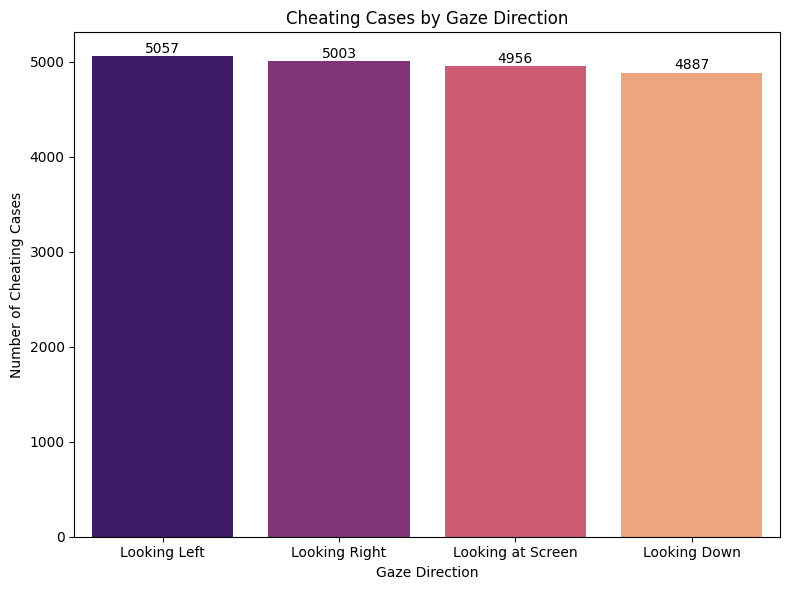

In [11]:

# Filter cheating cases by Gaze Direction
cheating_by_gaze = df[df['mobile_detected'] == 1]

# Count occurrences of each gaze direction among cheating cases
gaze_counts = cheating_by_gaze['gaze_direction'].value_counts()

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x=gaze_counts.index, y=gaze_counts.values, palette='magma')
plt.title('Cheating Cases by Gaze Direction')
plt.xlabel('Gaze Direction')
plt.ylabel('Number of Cheating Cases')

# Add count labels on top of bars
for i, v in enumerate(gaze_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

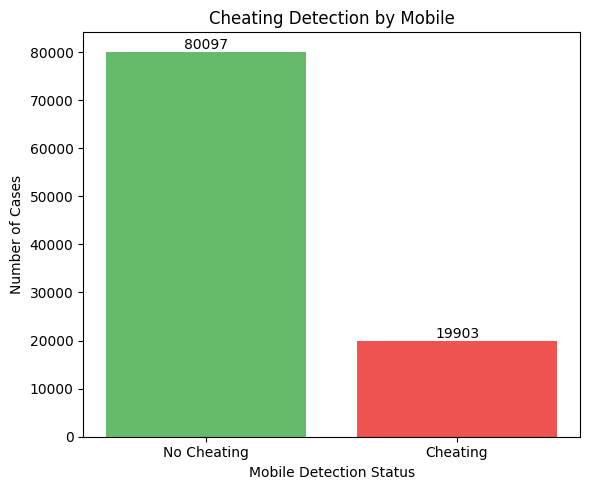

In [14]:
# Filter cheating cases by Mobile Detection
cheating_by_mobile = df[df['mobile_detected'] == 1]

# Count total cheating and non-cheating cases by mobile detection
mobile_counts = df['mobile_detected'].value_counts().sort_index()

# Plot
labels = ['No Cheating', 'Cheating']
plt.figure(figsize=(6, 5))
plt.bar(labels, mobile_counts, color=['#66bb6a', '#ef5350'])
plt.title('Cheating Detection by Mobile')
plt.xlabel('Mobile Detection Status')
plt.ylabel('Number of Cases')

# Add count labels
for i, v in enumerate(mobile_counts):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


Model Train

In [ ]:
# Label encode all object (string) columns
X = df.drop(columns=['timestamp'])  # drop timestamp

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['head_direction'] = le.fit_transform(df['head_direction'])
df['gaze_direction'] = le.fit_transform(df['gaze_direction'])
df['mobile_detected'] = df['mobile_detected'].astype(int)

In [16]:
# Split data
X = df[['head_direction', 'gaze_direction', 'mobile_detected']]
y = df['cheating']

In [17]:
print("Class distribution in y:")
print(y.value_counts())

Class distribution in y:
cheating
1    53171
0    46829
Name: count, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(y.unique())}")



Training set size: 80000
Test set size: 20000
Number of features: 3
Number of classes: 2


In [20]:
# Models to evaluate
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear', random_state=42)
}

# Store accuracies for comparison
accuracies = {}

In [21]:
# Train and evaluate each model
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{model_name} Accuracy: {acc:.2f}")
    accuracies[model_name] = acc

Decision Tree Accuracy: 0.70
Random Forest Accuracy: 0.70
Logistic Regression Accuracy: 0.67
SVM Accuracy: 0.67



=== Decision Tree ===


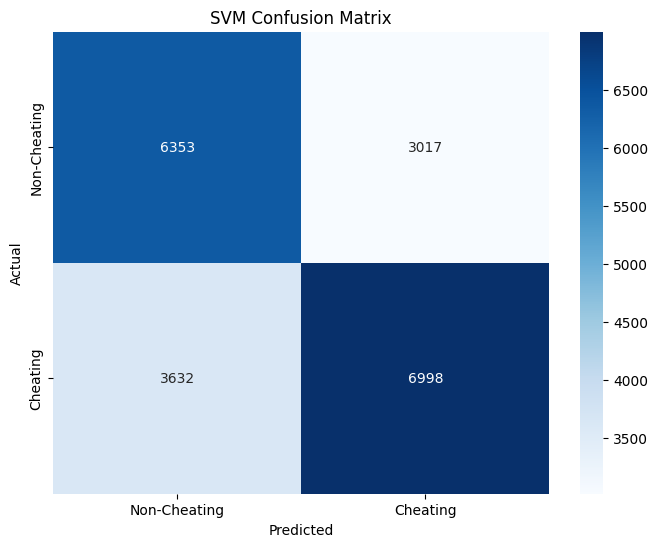


=== Random Forest ===


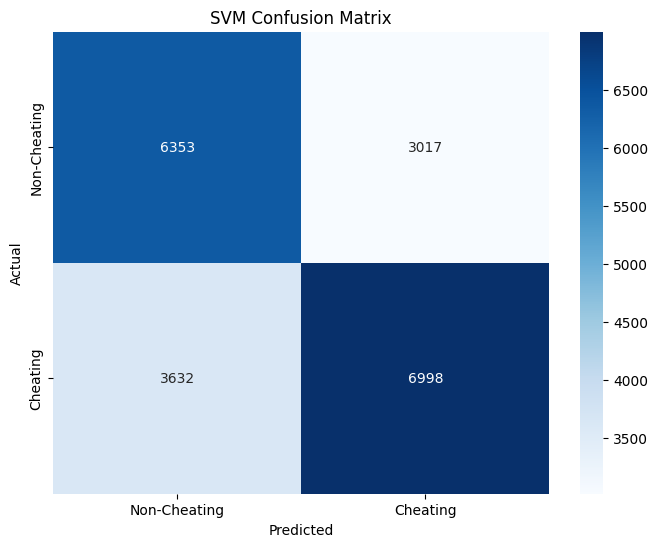


=== Logistic Regression ===


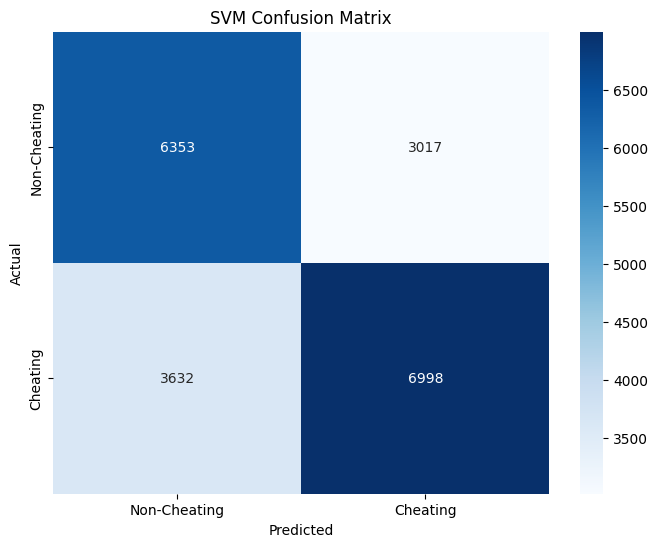


=== SVM ===


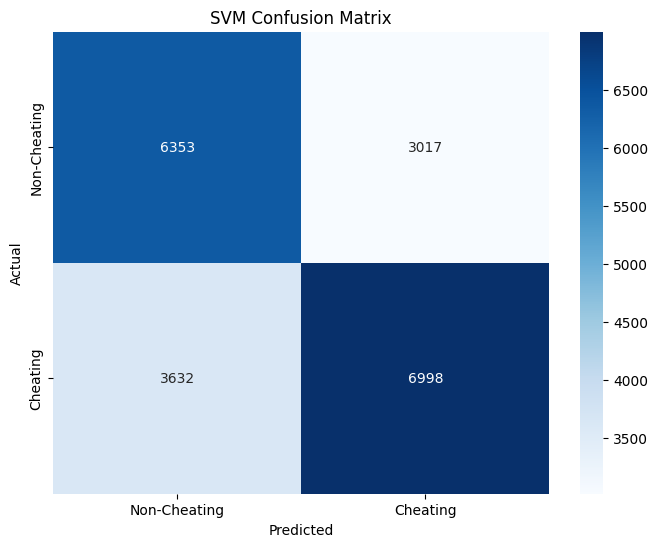

In [22]:
# Plot confusion matrix
for name, model in models.items():
    print(f"\n=== {name} ===")
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Cheating', 'Cheating'], yticklabels=['Non-Cheating', 'Cheating'])
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


The best model is: Decision Tree with an accuracy of 0.70


C:\Users\DESKTOP\AppData\Local\Temp\ipykernel_1964\2569166688.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')


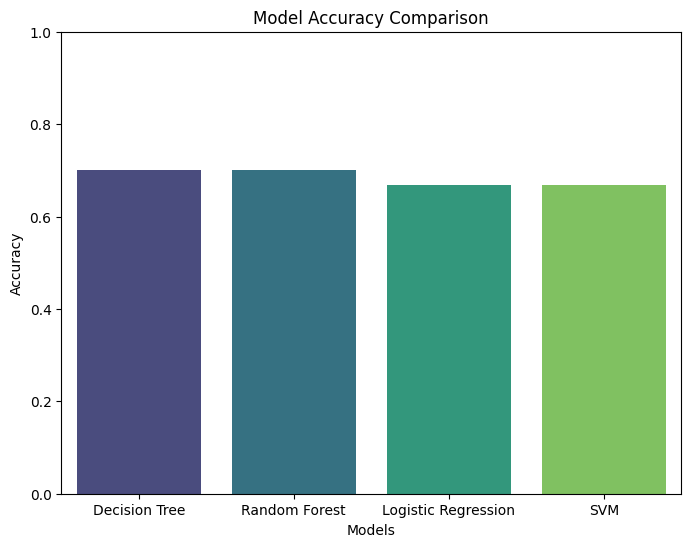

In [23]:
# Identify the best model
best_model_name = max(accuracies, key=accuracies.get)
best_model_accuracy = accuracies[best_model_name]
print(f"\nThe best model is: {best_model_name} with an accuracy of {best_model_accuracy:.2f}")

# Plot accuracy comparison
plt.figure(figsize=(8, 6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()


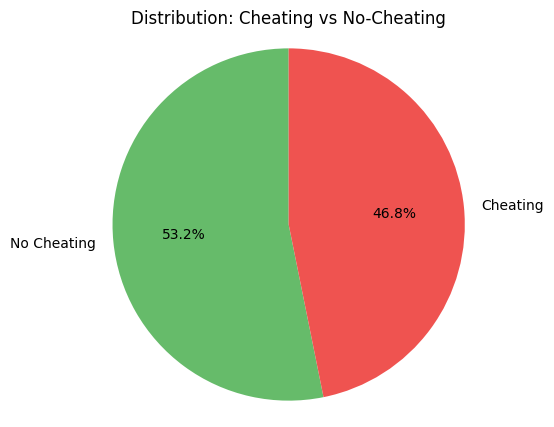

In [24]:
# Pie Chart of entire dataset (not model specific)
cheat_counts = pd.Series(y).value_counts()
plt.figure(figsize=(5,5))
plt.pie(cheat_counts, labels=['No Cheating', 'Cheating'], autopct='%1.1f%%', startangle=90, colors=['#66bb6a', '#ef5350'])
plt.title('Distribution: Cheating vs No-Cheating')
plt.axis('equal')
plt.show()

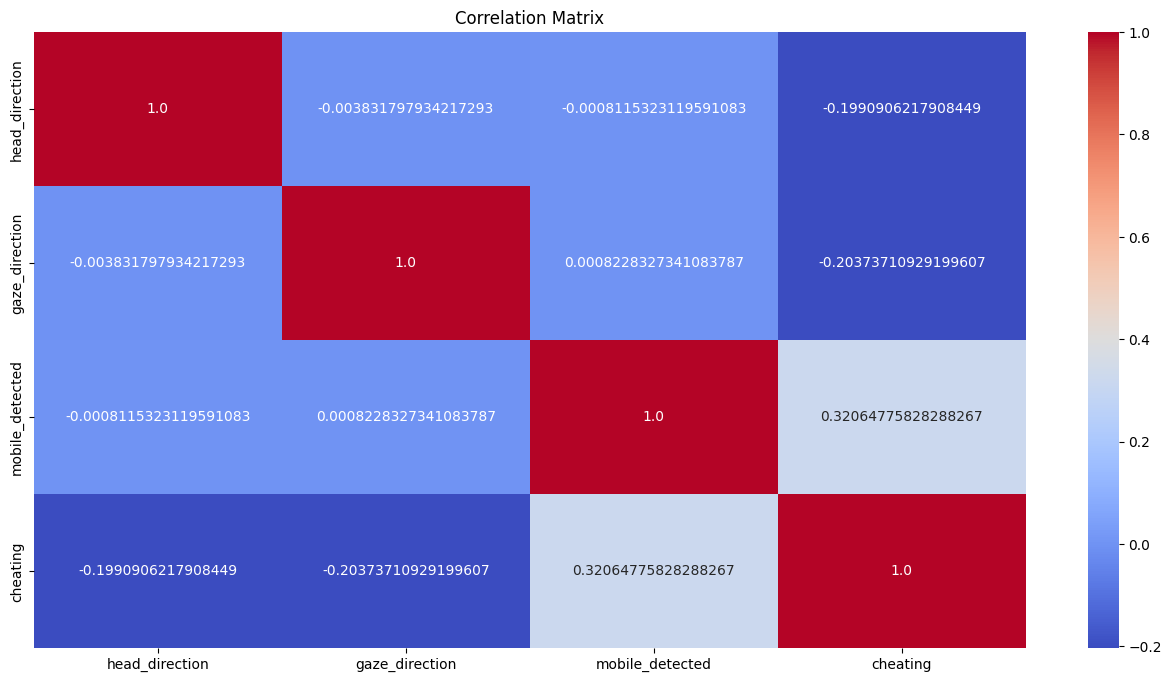

In [25]:
# Visualize the correlation matrix
plt.figure(figsize=(16, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt="")
plt.title("Correlation Matrix")
plt.show()